# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

Скользящее среднее – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


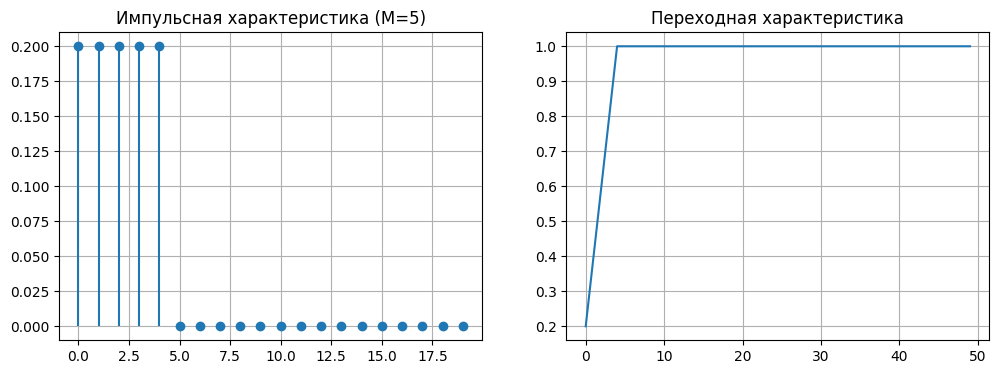

In [26]:
M = 5
b = np.ones(M) / M
a = [1]

impulse = np.zeros(20)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)

step = np.ones(50)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (M={M})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()


Вопрос: Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


Ответ: импульсная характеристика имеет конечную длину, так как фильтр нерекурсивный (КИХ), и его отклик ограничен размером заданного окна. переходная характеристика выходит на постоянный уровень, потому что при постоянном входе сумма всех коэффициентов фильтра равна единице, и выходной сигнал стабилизируется.


### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


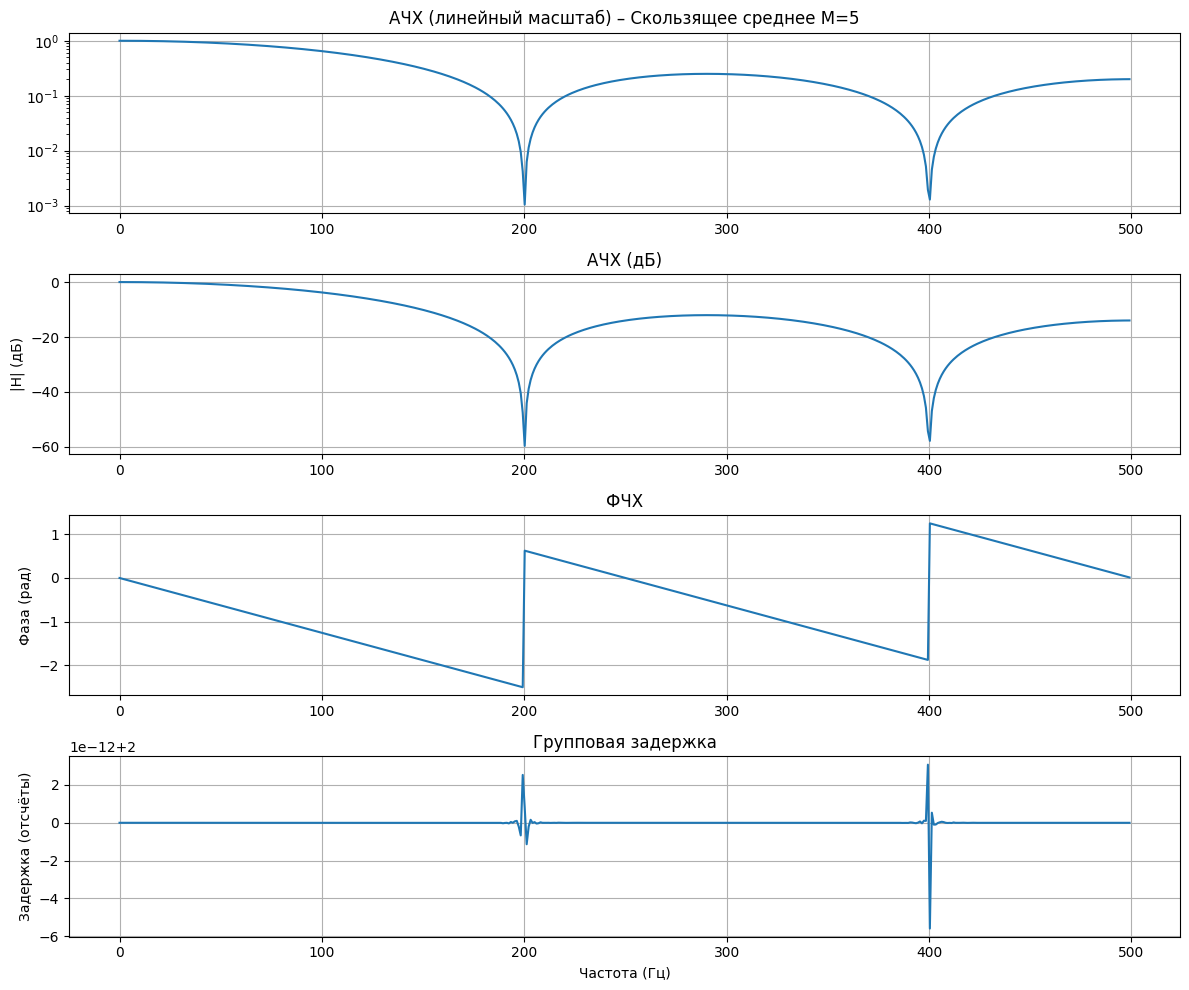

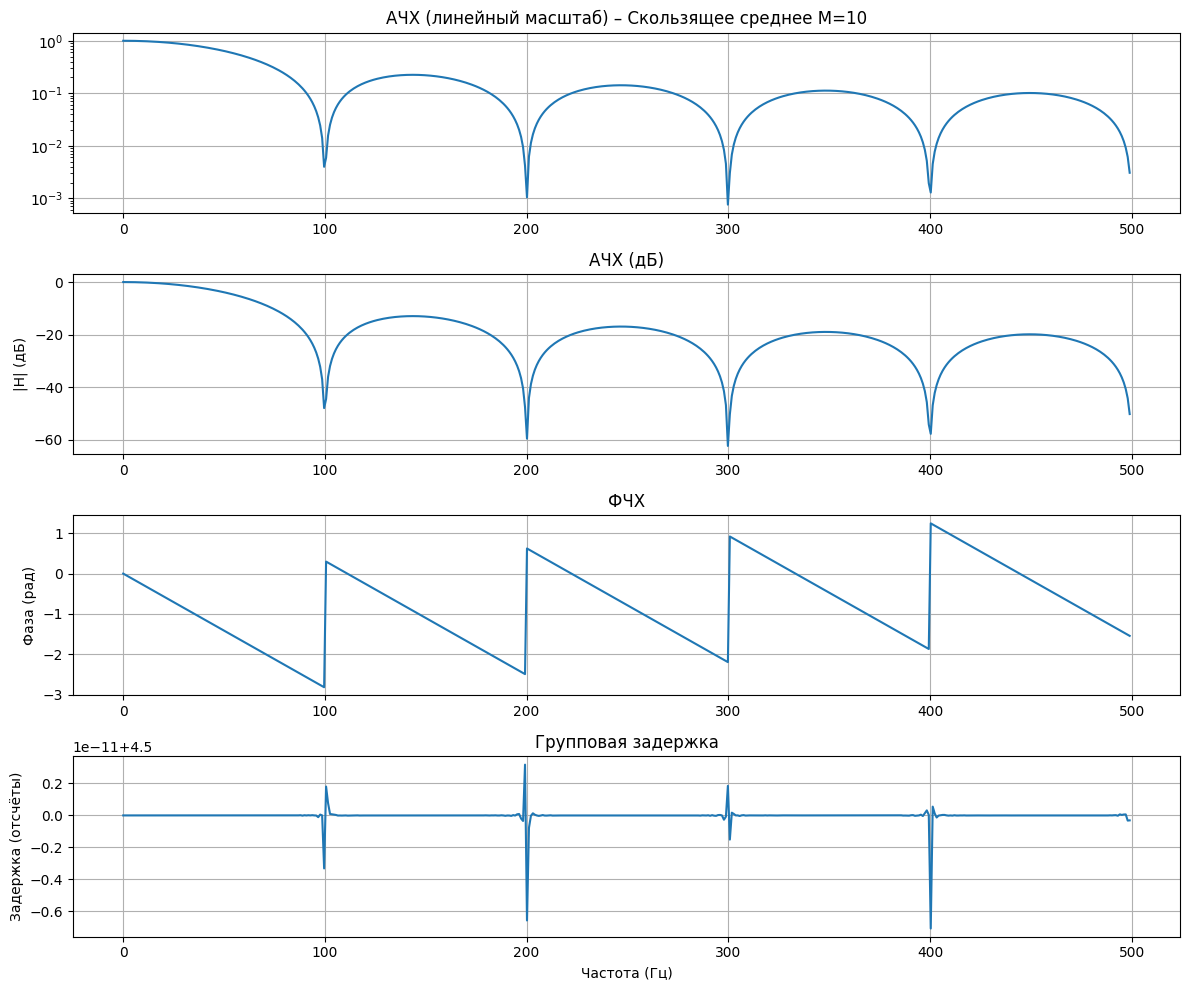

/tmp/ipykernel_27880/3756160993.py:16: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


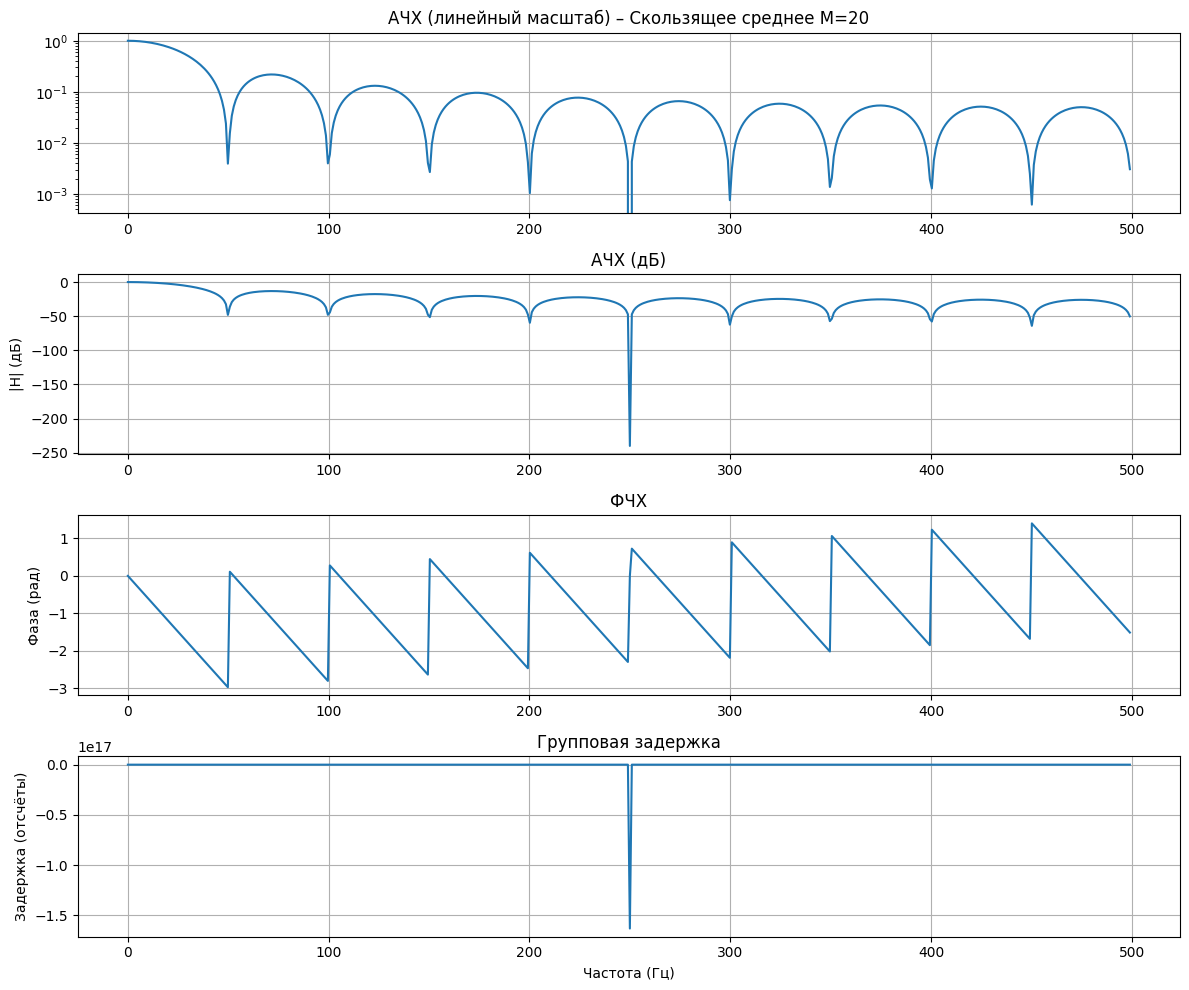

In [27]:
b5 = np.ones(5)/5
plot_filter_response(b5, [1], fs=1000, title='Скользящее среднее M=5')

b10 = np.ones(10)/10
plot_filter_response(b10, [1], fs=1000, title='Скользящее среднее M=10')

b20 = np.ones(20)/20
plot_filter_response(b20, [1], fs=1000, title='Скользящее среднее M=20')


Вопрос: Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?


Ответ: увеличение длины окна сужает полосу пропускания, делая срез АЧХ более крутым, и сильнее давит высокие частоты. фазово-частотная характеристика остается линейной, но ее наклон возрастает, что означает увеличение групповой задержки сигнала.


### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


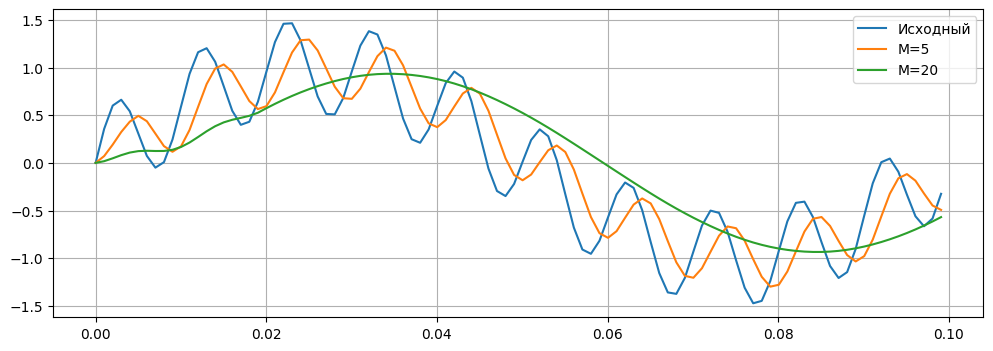

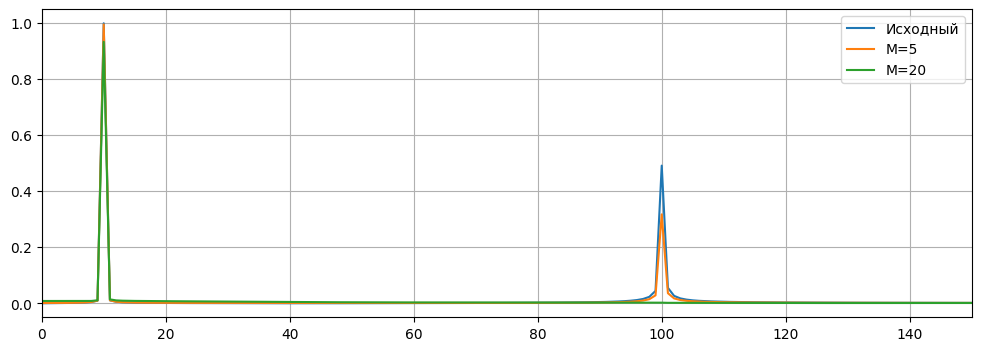

In [28]:
fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*100*t)

y5 = signal.lfilter(b5, [1], x)
y20 = signal.lfilter(b20, [1], x)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x[:100], label='Исходный')
plt.plot(t[:100], y5[:100], label='M=5')
plt.plot(t[:100], y20[:100], label='M=20')
plt.legend()
plt.grid()
plt.show()

def plot_spectrum(s, label):
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(len(s), 1/fs)
    plt.plot(freq[:len(freq)//2], np.abs(X[:len(freq)//2])/(len(s)//2), label=label)

plt.figure(figsize=(12,4))
plot_spectrum(x, 'Исходный')
plot_spectrum(y5, 'M=5')
plot_spectrum(y20, 'M=20')
plt.xlim(0, 150)
plt.legend()
plt.grid()
plt.show()


Вопрос: Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


Ответ: чем больше M, тем сильнее снижается амплитуда сигнала на частоте 100 Гц. это происходит из-за того, что при увеличении окна полоса пропускания фильтра сужается. график АЧХ показывает, что коэффициент передачи на частоте 100 Гц при M=20 падает значительно сильнее, чем при M=5, что напрямую влияет на амплитуду этой компоненты после фильтрации.


## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


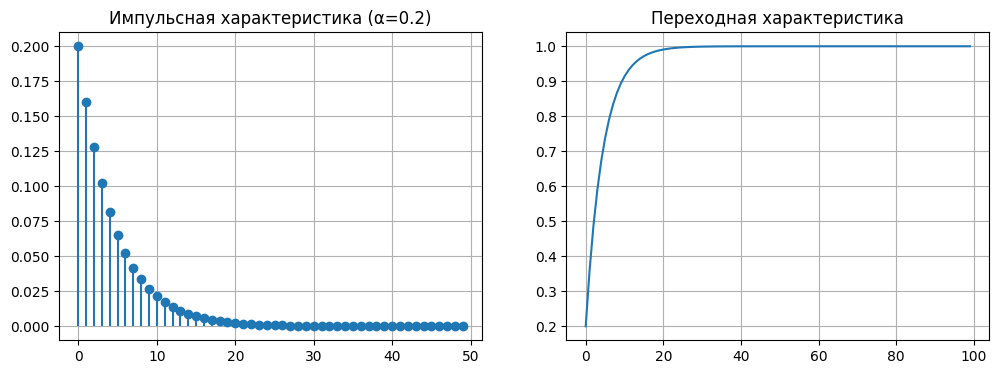

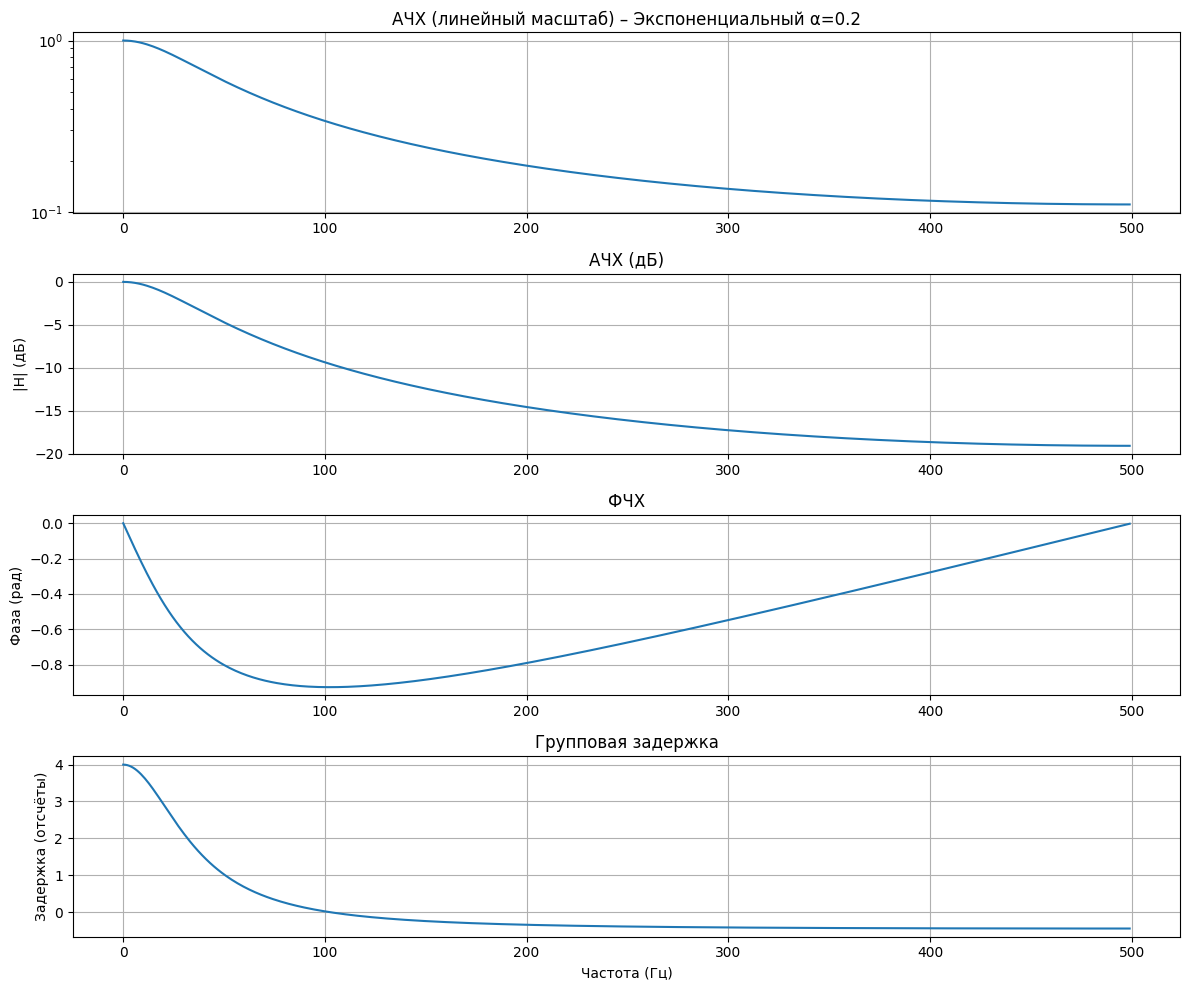

In [29]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)
step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

# Частотные характеристики
plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')


### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


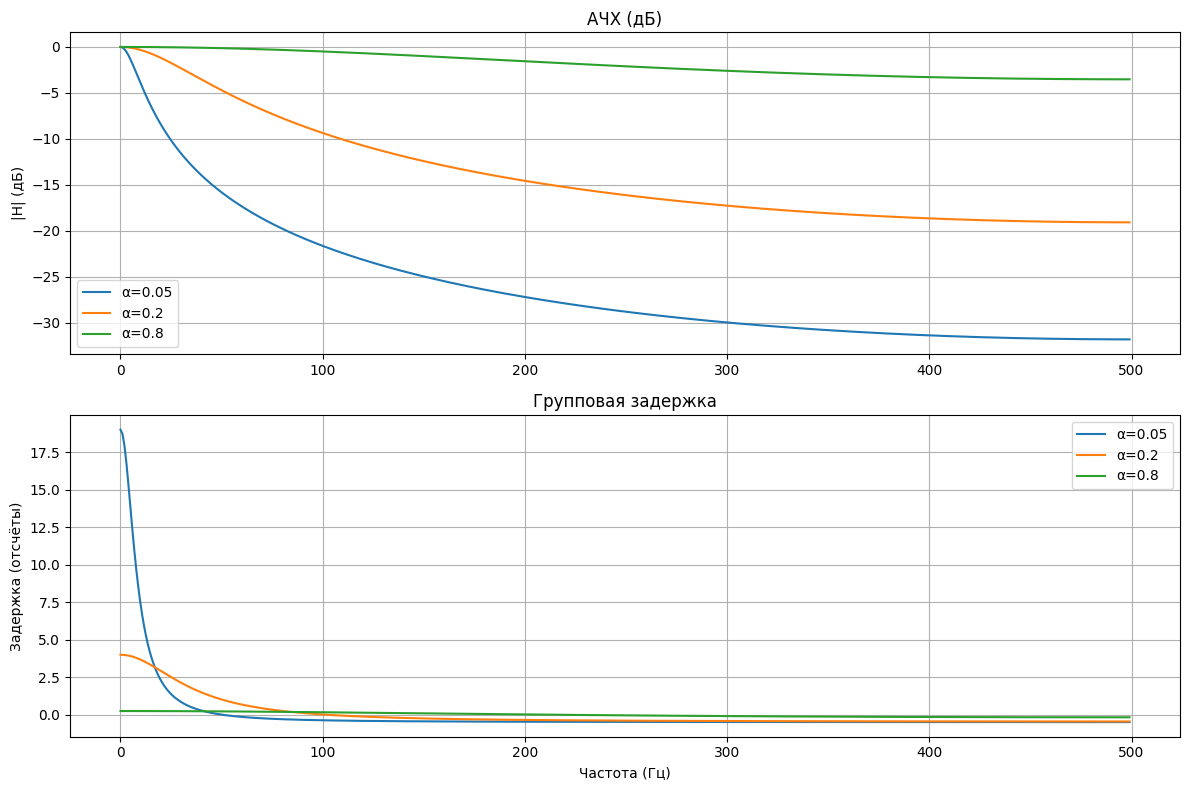

In [30]:
alphas = [0.05, 0.2, 0.8]
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
for alpha in alphas:
    b = [alpha]
    a = [1, -(1-alpha)]
    w, H = signal.freqz(b, a, fs=1000)
    plt.plot(w, 20*np.log10(np.abs(H) + 1e-12), label=f'α={alpha}')
plt.title('АЧХ (дБ)')
plt.ylabel('|H| (дБ)')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
for alpha in alphas:
    b = [alpha]
    a = [1, -(1-alpha)]
    w, gd = signal.group_delay((b, a), fs=1000)
    plt.plot(w, gd, label=f'α={alpha}')
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


Вопрос: Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


Ответ: чем меньше альфа, тем медленнее фильтр реагирует на изменения, так как он больше опирается на прошлые значения. на АЧХ это выглядит как более крутой спад и сильное подавление высоких частот. большие значения альфа делают реакцию быстрой, но ухудшают качество сглаживания шума.


### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


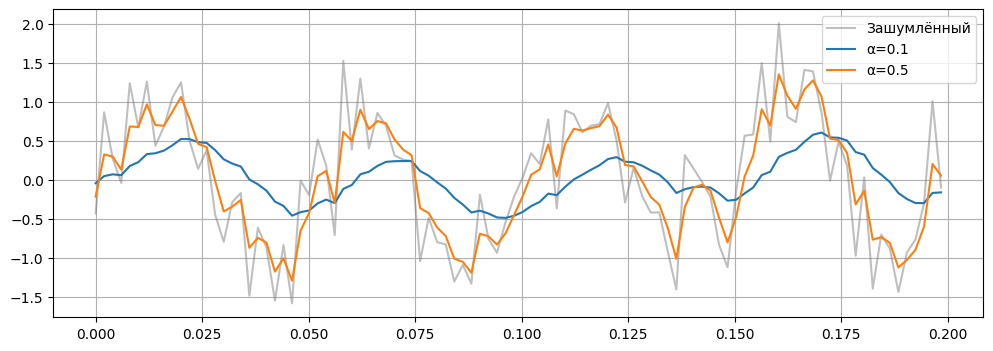

In [31]:
fs = 500
t = np.linspace(0, 1, fs)
x_clean = np.sin(2*np.pi*20*t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

y_01 = signal.lfilter([0.1], [1, -0.9], x_noisy)
y_05 = signal.lfilter([0.5], [1, -0.5], x_noisy)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x_noisy[:100], 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(t[:100], y_01[:100], label='α=0.1')
plt.plot(t[:100], y_05[:100], label='α=0.5')
plt.legend()
plt.grid()
plt.show()


Вопрос: Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


Ответ: на временных графиках задержка выглядит как горизонтальное смещение отфильтрованного сигнала вправо по оси времени по сравнению с исходным. чем сильнее фильтр сглаживает сигнал (меньше альфа), тем более заметным становится это запаздывание.


## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


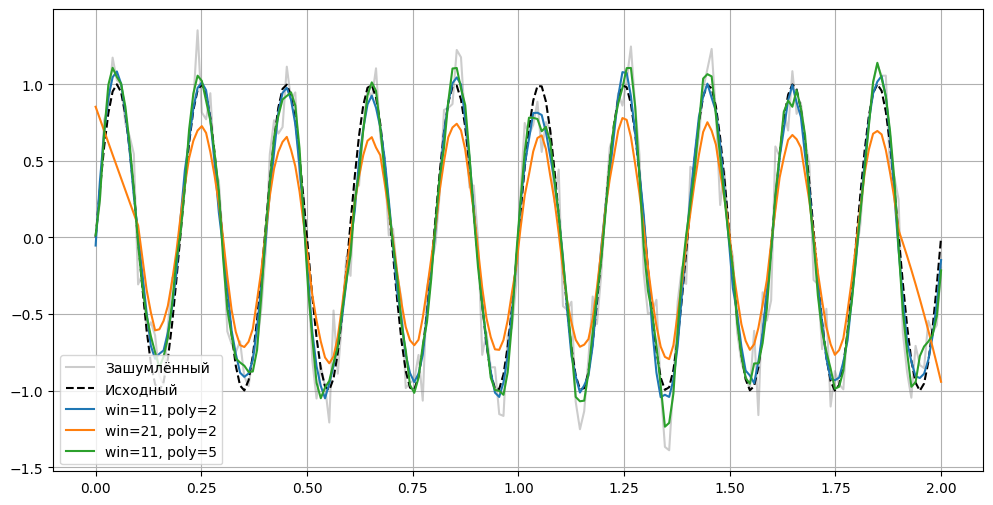

In [32]:
fs = 100
t = np.linspace(0, 2, 2*fs)
x_clean = np.sin(2*np.pi*5*t)
noise = 0.2 * np.random.randn(len(t))
x_noisy = x_clean + noise

y1 = savgol_filter(x_noisy, window_length=11, polyorder=2)
y2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
y3 = savgol_filter(x_noisy, window_length=11, polyorder=5)

plt.figure(figsize=(12,6))
plt.plot(t, x_noisy, 'gray', alpha=0.4, label='Зашумлённый')
plt.plot(t, x_clean, 'k--', label='Исходный')
plt.plot(t, y1, label='win=11, poly=2')
plt.plot(t, y2, label='win=21, poly=2')
plt.plot(t, y3, label='win=11, poly=5')
plt.legend()
plt.grid()
plt.show()


Вопрос 3.1: Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


Ответ: увеличение длины окна делает сглаживание шума более агрессивным, но может приводить к искажению резких изгибов сигнала. увеличение порядка полинома дает фильтру возможность точнее огибать форму исходного сигнала без срезания пиков, однако вместе с этим фильтр начинает пропускать больше высокочастотного шума.


### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


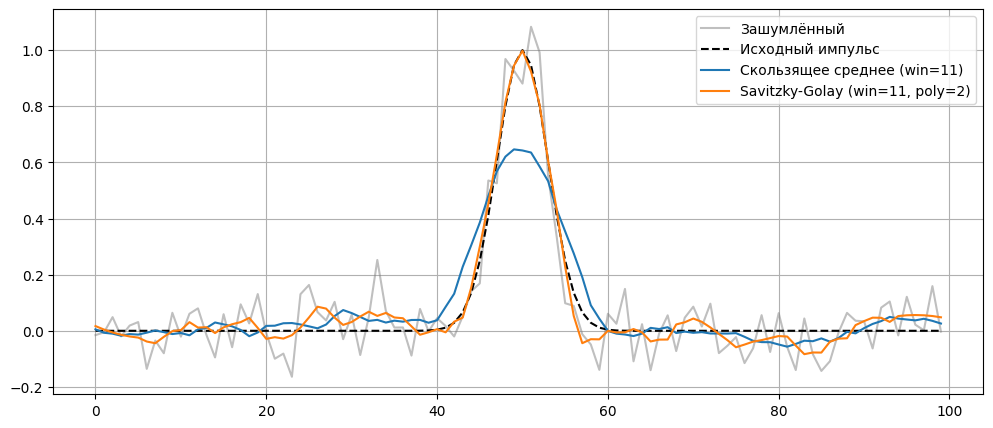

In [33]:
N = 100
x_pulse = np.zeros(N)
x_pulse[N//2] = 1
sigma = 3
gaussian = np.exp(-(np.arange(N)-N//2)**2/(2*sigma**2))
x_clean_pulse = gaussian / np.max(gaussian)
noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

y_ma = np.convolve(x_noisy_pulse, np.ones(11)/11, mode='same')
y_sg = savgol_filter(x_noisy_pulse, window_length=11, polyorder=2)

plt.figure(figsize=(12,5))
plt.plot(x_noisy_pulse, 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(x_clean_pulse, 'k--', label='Исходный импульс')
plt.plot(y_ma, label='Скользящее среднее (win=11)')
plt.plot(y_sg, label='Savitzky-Golay (win=11, poly=2)')
plt.legend()
plt.grid()
plt.show()


Вопрос: Какой из фильтров лучше сохраняет пик?


Ответ: фильтр Савицкого-Голея справляется заметно лучше. он сохраняет высоту и остроту пика, в то время как скользящее среднее сильно размазывает его, уменьшая максимальную амплитуду и увеличивая ширину.


### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


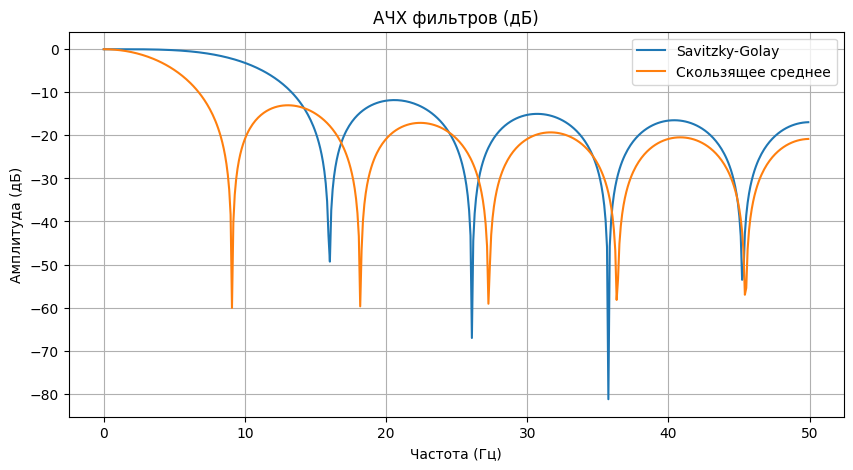

In [34]:
window_length = 11
polyorder = 2
coeffs = savgol_coeffs(window_length, polyorder)
coeffs = coeffs / np.sum(coeffs)

ma_coeffs = np.ones(11)/11

w_sg, H_sg = signal.freqz(coeffs, [1], fs=100)
w_ma, H_ma = signal.freqz(ma_coeffs, [1], fs=100)

plt.figure(figsize=(10, 5))
plt.plot(w_sg, 20*np.log10(np.abs(H_sg) + 1e-12), label='Savitzky-Golay')
plt.plot(w_ma, 20*np.log10(np.abs(H_ma) + 1e-12), label='Скользящее среднее')
plt.title('АЧХ фильтров (дБ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.legend()
plt.grid()
plt.show()


Вопрос: Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?


Ответ: АЧХ фильтра Савицкого-Голея спадает гораздо медленнее на низких и средних частотах, обеспечивая более широкую полосу пропускания. именно способность пропускать средние и высокие частоты без сильного ослабления позволяет этому фильтру сохранять резкие перепады и форму пиков.


### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


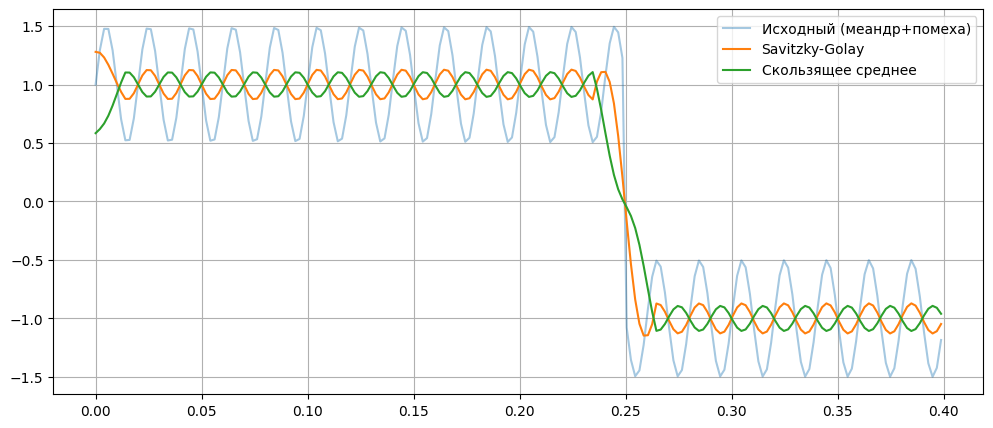

In [35]:
fs = 500
t = np.linspace(0, 1, fs)
meander = signal.square(2*np.pi*2*t)
interference = 0.5 * np.sin(2*np.pi*50*t)
x_meander = meander + interference

y_sg = savgol_filter(x_meander, window_length=15, polyorder=3)
y_ma = np.convolve(x_meander, np.ones(15)/15, mode='same')

plt.figure(figsize=(12,5))
plt.plot(t[:200], x_meander[:200], label='Исходный (меандр+помеха)', alpha=0.4)
plt.plot(t[:200], y_sg[:200], label='Savitzky-Golay')
plt.plot(t[:200], y_ma[:200], label='Скользящее среднее')
plt.legend()
plt.grid()
plt.show()


Вопрос: Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


Ответ: для сохранения резких фронтов лучше использовать фильтр Савицкого-Голея. он базируется на полиномиальной аппроксимации, что позволяет не заваливать крутые края импульсов так сильно, как это делает скользящее среднее. однако с периодической помехой скользящее среднее может справляться лучше из-за более сильного сглаживания.


## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


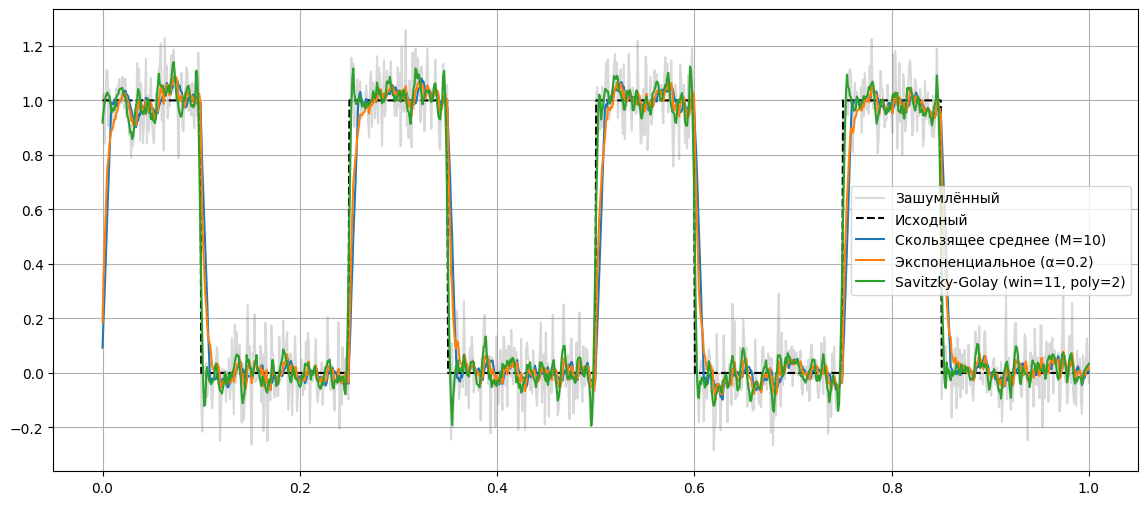

In [36]:
fs = 1000
t = np.linspace(0, 1, fs)
pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1
noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

b_ma = np.ones(10)/10
a_ma = [1]
y_ma = signal.lfilter(b_ma, a_ma, x_pulse_noisy)

alpha = 0.2
b_exp = [alpha]
a_exp = [1, -(1-alpha)]
y_exp = signal.lfilter(b_exp, a_exp, x_pulse_noisy)

y_sg = savgol_filter(x_pulse_noisy, window_length=11, polyorder=2)

plt.figure(figsize=(14, 6))
plt.plot(t, x_pulse_noisy, 'gray', alpha=0.3, label='Зашумлённый')
plt.plot(t, pulse_train, 'k--', label='Исходный')
plt.plot(t, y_ma, label='Скользящее среднее (M=10)')
plt.plot(t, y_exp, label='Экспоненциальное (α=0.2)')
plt.plot(t, y_sg, label='Savitzky-Golay (win=11, poly=2)')
plt.legend()
plt.grid()
plt.show()


Вопрос: Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


Ответ: экспоненциальный фильтр и скользящее среднее справляются с подавлением шума лучше всего, но сильно сглаживают фронты. фильтр Савицкого-Голея является лидером в сохранении крутизны фронтов прямоугольных импульсов. также Савицкий-Голей обладает наименьшими фазовыми искажениями, так как он реализован симметричным окном, не создающим смещения во времени, тогда как остальные вносят заметную задержку.
